In [16]:
import numpy as np
import matplotlib.pyplot as plt

****
## Problem 1

In [21]:
A = np.array([
    [289,2064,336,128,80,32,16],
    [1152,30,1312,512,288,128,32],
    [-29,-2000,756,384,1008,224,48],
    [512,128,640,0,640,512,128],
    [1053,2256,-504,-384,-756,800,208],
    [-287,-16,1712,-128,1968,-30,2032],
    [-2176,-287,-1565,-512,-541,1152,-289]
])
A

array([[  289,  2064,   336,   128,    80,    32,    16],
       [ 1152,    30,  1312,   512,   288,   128,    32],
       [  -29, -2000,   756,   384,  1008,   224,    48],
       [  512,   128,   640,     0,   640,   512,   128],
       [ 1053,  2256,  -504,  -384,  -756,   800,   208],
       [ -287,   -16,  1712,  -128,  1968,   -30,  2032],
       [-2176,  -287, -1565,  -512,  -541,  1152,  -289]])

In [10]:
P = np.array([
    [0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0],
    [0,0,0,0,0,1,0],
    [0,0,0,0,0,0,1],
    [1,0,0,0,0,0,0],
    [0,1,0,0,0,0,0],
    [0,0,1,0,0,0,0]
])

In [11]:
B = P.T.dot(A.dot(P))

In [12]:
C = P.T.dot(B.dot(P))

In [17]:
A_eval = np.linalg.eig(A)[0]

In [18]:
B_eval = np.linalg.eig(B)[0]

In [19]:
C_eval = np.linalg.eig(C)[0]

In [25]:
np.sort(A_eval)

array([-2145.32222847   +0.j        , -1078.72260751   +0.j        ,
        -210.52818381-1190.92684291j,  -210.52818381+1190.92684291j,
        -187.35291571   +0.j        ,  1916.22705966 -718.86579878j,
        1916.22705966 +718.86579878j])

In [26]:
np.sort(B_eval)

array([-2145.32222847   +0.j        , -1078.72260751   +0.j        ,
        -210.52818381-1190.92684291j,  -210.52818381+1190.92684291j,
        -187.35291571   +0.j        ,  1916.22705966 -718.86579878j,
        1916.22705966 +718.86579878j])

In [27]:
np.sort(C_eval)

array([-2145.32222847   +0.j        , -1078.72260751   +0.j        ,
        -210.52818381-1190.92684291j,  -210.52818381+1190.92684291j,
        -187.35291571   +0.j        ,  1916.22705966 -718.86579878j,
        1916.22705966 +718.86579878j])

In [29]:
np.sort(A_eval)-np.sort(C_eval)

array([-9.09494702e-13+0.00000000e+00j, -1.81898940e-12+0.00000000e+00j,
        4.54747351e-13-2.50111043e-12j,  4.54747351e-13+2.50111043e-12j,
       -8.52651283e-14+0.00000000e+00j, -1.36424205e-12+1.25055521e-12j,
       -1.36424205e-12-1.25055521e-12j])

In [31]:
np.sort(A_eval)-np.sort(B_eval)

array([ 4.54747351e-13+0.00000000e+00j, -1.36424205e-12+0.00000000e+00j,
        3.12638804e-13-2.27373675e-12j,  3.12638804e-13+2.27373675e-12j,
        1.70530257e-13+0.00000000e+00j,  2.50111043e-12-9.09494702e-13j,
        2.50111043e-12+9.09494702e-13j])

In [32]:
np.sort(B_eval)-np.sort(C_eval)

array([-1.36424205e-12+0.00000000e+00j, -4.54747351e-13+0.00000000e+00j,
        1.42108547e-13-2.27373675e-13j,  1.42108547e-13+2.27373675e-13j,
       -2.55795385e-13+0.00000000e+00j, -3.86535248e-12+2.16004992e-12j,
       -3.86535248e-12-2.16004992e-12j])

These values are slightly different as different errors appear when performing QR on the three matrices.
****

## Problem 2

For $A$ as given, the characteristic polynomial is $\det{(\lambda I-A)} = (\lambda-8)(\lambda-1)+2=\lambda^2-9\lambda+10$. using the quadratic formula, we compute the zeros as:
$$
\lambda = \frac{9\pm\sqrt{81-40}}{2}=\frac{9\pm \sqrt{41}}{2}
$$

The greater of which is given below:

In [33]:
lam = (9+np.sqrt(41))/2
lam

7.701562118716424

In [34]:
q_0 = np.array([1,1])
A = np.array([[8,1],[-2,1]])

In [35]:
q_i = q_0
for i in range(20):
    q_i = A.dot(q_i)/np.linalg.norm(A.dot(q_i))

In [40]:
lamhat = np.linalg.norm(A.dot(q_i))

lamhat

7.701562118716426

In [41]:
ratio_list = []
qi= q_0
for i in range(20):
    q_prev = qi
    qi = A.dot(qi)/np.linalg.norm(A.dot(qi))
    ratio = np.linalg.norm(qi-q_i)/np.linalg.norm(q_prev-q_i)
    ratio_list.append(ratio)


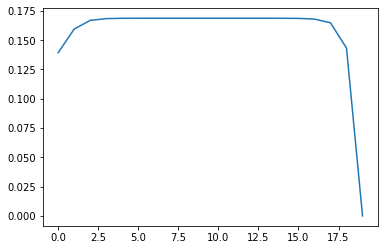

In [42]:
plt.plot(ratio_list)

In [43]:
eig_rat = (9-np.sqrt(41))/(9+np.sqrt(41))

In [44]:
eig_rat

0.16859409315521812

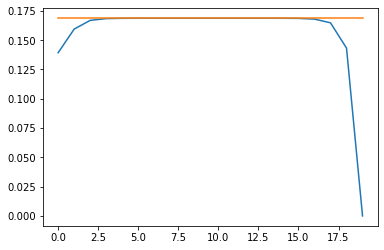

In [46]:
plt.plot(ratio_list)
plt.plot(eig_rat*np.ones(20))

In this case, I would say that the theory agrees with the practive very well.
****
## Problem 3

In [49]:
A = np.array([
    [1,1,1],
    [-1,9,2],
    [0,-1,2]
])

In [60]:
mu_0 = 1
b_0 = np.array([1,0,0])

b_i = b_0
mu_i = mu_0

for i in range(20):
    b_i = (np.linalg.inv(A-mu_i*np.eye(3)).dot(b_i))/(np.linalg.norm(np.linalg.inv(A-mu_i*np.eye(3)).dot(b_i)))
    
    mu_i = b_i.conj().dot(A.dot(b_i))/(b_i.conj().dot(b_i))

In [61]:
m1,b1=mu_i,b_i
m1,b1

(1.2206897466222533, array([0.98786135, 0.09548538, 0.1225255 ]))

In [62]:
mu_0 = 3
b_0 = np.array([0,0,1])

b_i = b_0
mu_i = mu_0

for i in range(20):
    b_i = (np.linalg.inv(A-mu_i*np.eye(3)).dot(b_i))/(np.linalg.norm(np.linalg.inv(A-mu_i*np.eye(3)).dot(b_i)))
    
    mu_i = b_i.conj().dot(A.dot(b_i))/(b_i.conj().dot(b_i))
    
m2,b2=mu_i,b_i
m2,b2

(2.194881913047255, array([ 0.55163424, -0.15954682,  0.8186846 ]))

In [64]:
mu_0 = 5
b_0 = np.array([0,1,0])

b_i = b_0
mu_i = mu_0

for i in range(20):
    b_i = (np.linalg.inv(A-mu_i*np.eye(3)).dot(b_i))/(np.linalg.norm(np.linalg.inv(A-mu_i*np.eye(3)).dot(b_i)))
    
    mu_i = b_i.conj().dot(A.dot(b_i))/(b_i.conj().dot(b_i))
    
m3,b3=mu_i,b_i
m3,b3

(8.584428340330492, array([ 0.10988743,  0.98267567, -0.14924237]))

In [76]:
#eigenvalues
m1,m2,m3

(1.2206897466222533, 2.194881913047255, 8.584428340330492)

In [77]:
#eigenvectors
b1,b2,b3

(array([0.98786135, 0.09548538, 0.1225255 ]),
 array([ 0.55163424, -0.15954682,  0.8186846 ]),
 array([ 0.10988743,  0.98267567, -0.14924237]))

In [93]:
# check to see that the eigenvectors are linearly independent: If they are, then a matrix formed by them will be
# nonsingular

B = np.array([b1,b2,b3])
B = B.T
np.linalg.det(B)

-0.6861960965514569

****
## Problem 4

In [94]:
def roots(coeffs):
    # this function takes the coefficents of a polynomial in an array and returns its roots.
    # the coefficients must be in descending order of term degree: that is,
    # position j of the array will contain the coefficient of the term of degree d-j, where
    # d is the degree of the polynomial.
    
    d = len(coeffs)
    
    C = np.zeros((d,d))
    C[0,:] = coeffs
    
    for i in range(1,d):
        C[i,i-1] = 1
    
    return np.linalg.eig(C)[0]